In [1]:
import sys
sys.version

'3.11.6 (tags/v3.11.6:8b6ee5b, Oct  2 2023, 14:57:12) [MSC v.1935 64 bit (AMD64)]'

In [1]:
import numpy as np
import keras
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from keras.datasets import imdb
from time import time
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import f1_score
from sklearn.metrics.pairwise import cosine_similarity
from tmu.models.autoencoder.autoencoder import TMAutoEncoder

target_words = ['london', 'terrible', 'lousy', 'abysmal', 'crap', 'city', 'brilliant', 'excellent', 'superb', 'magnificent', 'marvellous', 'truck', 'plane', 'car', 'cars', 'motorcycle',  'scary', 'frightening', 'terrifying', 'horrifying', 'funny', 'comic', 'hilarious', 'witty']

clause_weight_threshold = 0
number_of_examples = 4000
factor = 4
T = factor*40
s = 5.0

remove_categories = True
categories = 4
accumulation = categories * 6

NUM_WORDS=10000
INDEX_FROM=2

2023-11-29 13:25:02,714 - tmu.util.cuda_profiler - WARNING - Could not import pycuda: No module named 'pycuda'
2023-11-29 13:25:02,716 - tmu.clause_bank.clause_bank_cuda - ERROR - No module named 'pycuda'
Traceback (most recent call last):
  File "C:\Users\ahmedkk\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tmu\clause_bank\clause_bank_cuda.py", line 41, in <module>
    from pycuda._driver import Device, Context
ModuleNotFoundError: No module named 'pycuda'
2023-11-29 13:25:02,735 - tmu.clause_bank.clause_bank_cuda - WARNING - Could not import pycuda. This indicates that it is not installed! A possible fix is to run 'pip install pycuda'. Fallback to CPU ClauseBanks.


In [2]:
train,test = keras.datasets.imdb.load_data(num_words=NUM_WORDS, index_from=INDEX_FROM)
train_x,train_y = train
test_x,test_y = test
print("the number of reviews in train set =",train_x.size)
word_to_id = keras.datasets.imdb.get_word_index()
word_to_id = {k:(v+INDEX_FROM) for k,v in word_to_id.items()}

word_to_id["<PAD>"] = 0
word_to_id["<START>"] = 1
word_to_id["<UNK>"] = 2

id_to_word = {value:key for key,value in word_to_id.items()}
training_documents = []
for i in range(train_y.shape[0]):
    terms = []
    for word_id in train_x[i]:
        terms.append(id_to_word[word_id].lower())
              
    training_documents.append(terms)

testing_documents = []
for i in range(test_y.shape[0]):
    terms = []
    for word_id in test_x[i]:
        terms.append(id_to_word[word_id].lower())

    testing_documents.append(terms)
def tokenizer(s):
    return s

vectorizer_X = CountVectorizer(tokenizer=tokenizer, lowercase=False, binary = remove_categories)
X_train = vectorizer_X.fit_transform(training_documents)
feature_names = vectorizer_X.get_feature_names_out()
number_of_features = vectorizer_X.get_feature_names_out().shape[0]
X_test = vectorizer_X.transform(testing_documents)
output_active = np.empty(len(target_words), dtype=np.uint32)
for i in range(len(target_words)):
    target_word = target_words[i]
    target_id = vectorizer_X.vocabulary_[target_word]
    output_active[i] = target_id

the number of reviews in train set = 25000


C:\Users\ahmedkk\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\feature_extraction\text.py:525: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [3]:
import os
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

num_segments = len(target_words)
step_size = int(360 / num_segments)
color_dict = {}
hue = 0
for word in target_words:
    # color = plt.get_cmap('hsv')(hue / 360.0)
    # r, g, b, _ = color
    # r = int(r * 255)
    # g = int(g * 255)
    # b = int(b * 255)
    # color_dict[word] = (r, g, b)
    # hue += step_size
    color = plt.get_cmap('hsv')(hue / 360.0)
    color = mcolors.to_rgb(color)
    hex_color = mcolors.rgb2hex(color)
    color_dict[word] = hex_color
    hue += step_size

2023-11-29 13:25:11,344 - matplotlib - DEBUG - matplotlib data path: C:\Users\ahmedkk\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\matplotlib\mpl-data
2023-11-29 13:25:11,358 - matplotlib - DEBUG - CONFIGDIR=C:\Users\ahmedkk\.matplotlib
2023-11-29 13:25:11,361 - matplotlib - DEBUG - interactive is False
2023-11-29 13:25:11,362 - matplotlib - DEBUG - platform is win32
2023-11-29 13:25:11,554 - matplotlib - DEBUG - CACHEDIR=C:\Users\ahmedkk\.matplotlib
2023-11-29 13:25:11,573 - matplotlib.font_manager - DEBUG - Using fontManager instance from C:\Users\ahmedkk\.matplotlib\fontlist-v330.json


In [6]:
clauses = factor*10

if remove_categories:
    tm = TMAutoEncoder(clauses, T, s, output_active, max_included_literals=3, accumulation=accumulation, feature_negation=False, platform='CPU', output_balancing=True)
else:
    tm = TMAutoEncoder(clauses, T, s, output_active, max_included_literals=3, accumulation=accumulation, feature_negation=False, platform='CPU', output_balancing=True, categories=categories)
epochs = 1
print("\nAccuracy Over %d Epochs:" % epochs)
total_training = 0

for e in range(epochs):
    start_training = time()
    tm.fit(X_train, number_of_examples=number_of_examples)
    stop_training = time()
    total_training = total_training + (stop_training - start_training)

    print("\nEpoch #%d\n" % (e+1))

    print("Algorithm: %s " % ("Original without categories" if (remove_categories == True) else "With"), end="")
    if(remove_categories == False): 
        print("%d categories" % categories) 
    else: 
        print("\n")
    print("Epochs: %d" % epochs)
    print("Example: %d" % number_of_examples)
    print("Target words: %d" % len(target_words))
    print("Accumulation: %d" % accumulation)
    print("Clauses: %d" % clauses)
    # print("Calculating precision and recall\n")
    # precision = []
    # recall = []
    # for i in range(len(target_words)):
    #     pres, rec = tm.clause_precision_recall(i, True, X_train, number_of_examples=500)
    #     precision.append(pres)
    #     recall.append(rec)

    # precision = []
    # for i in range(len(target_words)):
    #     precision.append(tm.clause_precision(i, True, X_train, number_of_examples=500))

    # recall = []
    # print("Calculating recall\n")
    # for i in range(len(target_words)):
    #     recall.append(tm.clause_recall(i, True, X_train, number_of_examples=500))

    # print("Clauses\n")
    # for j in range(clauses):
    #     print("Clause #%d " % (j), end=' ')
    #     for i in range(len(target_words)):
    #         print("%s:W%d:P%.2f:R%.2f " % (target_words[i], tm.get_weight(i, j), precision[i][j], recall[i][j]), end=' ')

    #     l = []
    #     for k in range(tm.clause_bank.number_of_literals):
    #         if tm.get_ta_action(j, k) == 1:
    #             if k < tm.clause_bank.number_of_features:
    #                 l.append("%s(%d)" % (feature_names[k], tm.clause_bank.get_ta_state(j, k)))
    #             else:
    #                 l.append("¬%s(%d)" % (feature_names[k-tm.clause_bank.number_of_features], tm.clause_bank.get_ta_state(j, k)))
    #     print(" ∧ ".join(l))

    profile = np.empty((len(target_words), clauses))
    for i in range(len(target_words)):
        weights = tm.get_weights(i)
        profile[i,:] = np.where(weights >= clause_weight_threshold, weights, 0)

    similarity = cosine_similarity(profile)

    print("\n=====================================\nWord Similarity\n=====================================")
    max_word_length = len(max(target_words, key=len))
    list_of_words = []
    target_words_with_min_max = []
    for i in range(len(target_words)):
        row_of_similarity = []
        sorted_index = np.argsort(-1*similarity[i,:])
        min_similarity = 1.0
        max_similarity = 0.0
        word_similarity = []
        for j in range(1, len(target_words)):
            row_of_similarity.append(target_words[sorted_index[j]])
            word_similarity.append("{:<{}}({:.2f})  ".format(target_words[sorted_index[j]], max_word_length, similarity[i, sorted_index[j]]))
            if(min_similarity > similarity[i,sorted_index[j]]):
                min_similarity = similarity[i,sorted_index[j]]
            if(max_similarity < similarity[i,sorted_index[j]]):
                max_similarity = similarity[i,sorted_index[j]]
                
        output_line = f"{target_words[i]:<{max_word_length}}: Min:{min_similarity:.2f}, Max:{max_similarity:.2f}"
        print(output_line, end='     ==> ')
        # print(f"{target_words[i]:<{max_word_length}}:", end=' ')
        # print("Min:%.2f, Max:%.2f" % (min_similarity,max_similarity), end='     ==> ')
        print(word_similarity)
        list_of_words.append(row_of_similarity)
        target_words_with_min_max.append(output_line)

print("\nTraining Time:%d" % (total_training))


Accuracy Over 1 Epochs:
Fit with categories

Epoch #1

Algorithm: With 4 categories
Epochs: 1
Example: 4000
Target words: 24
Accumulation: 24
Clauses: 40

Word Similarity
london     : Min:0.07, Max:0.57     ==> ['city       (0.57)  ', 'comic      (0.52)  ', 'terrifying (0.44)  ', 'car        (0.44)  ', 'motorcycle (0.41)  ', 'crap       (0.40)  ', 'abysmal    (0.39)  ', 'truck      (0.38)  ', 'funny      (0.36)  ', 'cars       (0.35)  ', 'superb     (0.34)  ', 'plane      (0.34)  ', 'scary      (0.30)  ', 'marvellous (0.28)  ', 'terrible   (0.28)  ', 'excellent  (0.26)  ', 'magnificent(0.22)  ', 'lousy      (0.21)  ', 'witty      (0.19)  ', 'horrifying (0.18)  ', 'frightening(0.16)  ', 'brilliant  (0.14)  ', 'hilarious  (0.07)  ']
terrible   : Min:0.06, Max:0.55     ==> ['car        (0.55)  ', 'plane      (0.51)  ', 'hilarious  (0.49)  ', 'funny      (0.44)  ', 'frightening(0.37)  ', 'motorcycle (0.36)  ', 'crap       (0.35)  ', 'cars       (0.34)  ', 'scary      (0.34)  ', 'marvellou

2023-11-29 13:25:45,724 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2023-11-29 13:25:45,726 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2023-11-29 13:25:45,733 - matplotlib.font_manager - DEBUG - findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
2023-11-29 13:25:45,735 - matplotlib.font_manager - DEBUG - findfont: score(FontEntry(fname='C:\\Users\\ahmedkk\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\STIXSizTwoSymBol.ttf', name='STIXSizeTwoSym', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
2023-11-29 13:25:45,735 - matplotlib.font_manager - DEBUG - findfont: score(FontEntry(fname='C:\\Users\\ahmedkk\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Pytho

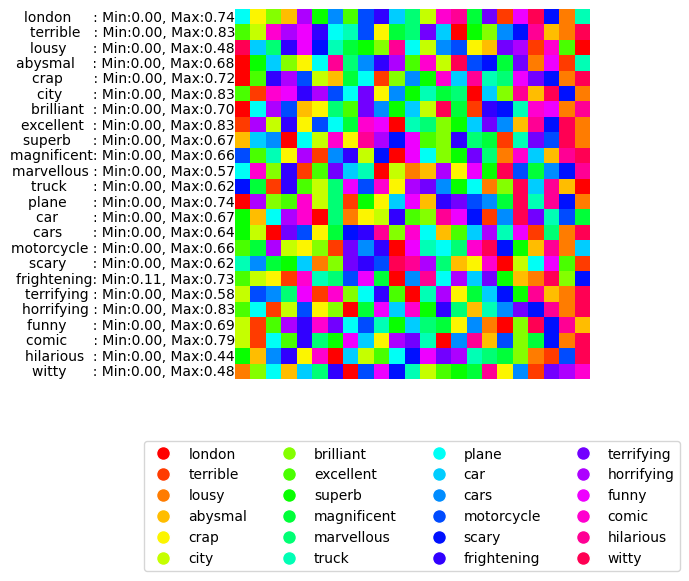

In [5]:
# Create a new folder for this run of the script
if not os.path.exists('color_plots'):
    os.makedirs('color_plots')
plot_filename = f'color_plots/plot_{clauses}.png'

# Create a new 3D array with the same shape as list_of_words, with dtype=np.uint8
color_array = np.zeros((len(list_of_words), len(list_of_words[0]), 3), dtype=np.uint8)

# Loop through each element in the array and replace the word with its corresponding color
for i in range(len(list_of_words)):
    for j in range(len(list_of_words[i])):
        word = list_of_words[i][j]
        # Replace the word with its corresponding color
        color = color_dict[word]
        r, g, b = mcolors.hex2color(color)
        color_array[i][j] = np.array([r*255, g*255, b*255], dtype=np.uint8)

    # Add the row number in front of each row
    plt.text(-0.5, i, f'{target_words_with_min_max[i]}', ha='right', va='center')

# Create a plot of the color array
plt.imshow(color_array)
plt.axis('off')

# Add legends for each word color
legend_handles = []
legend_labels = []
for word, color in color_dict.items():
    legend_handles.append(plt.Line2D([0], [0], marker='o', color='w', label=word, markerfacecolor=color, markersize=10))
    legend_labels.append(word)

plt.legend(handles=legend_handles, labels=legend_labels, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4)

# Save the plot as a PNG file
plt.savefig('color_plots/color_plot.png', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()